In [1]:
# imports
import os
import pandas as pd
import numpy as np
import json
import random 
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import re
import glob
from TrackReconstruction_functions import *
import sys
from io import StringIO


## Functions

In [2]:
def get_zshift(pressure):
    density = 5.987*pressure
    M = 1000/0.9
    det_size = 1000*np.cbrt((4 * M) / (np.pi * density))/2.0

    return det_size

z_shift = get_zshift(1)

In [3]:
#-----GET VERTEX------
def get_vertex(part, eid):

    x_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_x.iloc[0]
    y_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_y.iloc[0]
    z_vertex = part[(part.event_id == eid) & (part.particle_id == 1)].initial_z.iloc[0]

    return x_vertex, y_vertex, z_vertex

In [4]:
def get_node_centers_df(hits_df, eid, pressure, diffusion):
    #print(f"diffusion: {diffusion}")
    #print(f"pressure: {pressure}")
    data = hits_df[hits_df["event_id"] == int(eid)].copy()
    if np.isnan(data.z.mean()) or data.z.empty:
        print(f"Skipping event {eid} because hits are missing or invalid")
        return pd.DataFrame()
    Diff_smear, energy_threshold, diff_scale_factor, radius_sf, group_sf, Tortuosity_dist, voxel_size, det_size  = InitializeParams(pressure, diffusion)

    if (diffusion == "next1t"):
        mean_sigma=6
    elif (diffusion == "nodiff"):
        mean_sigma=10/np.sqrt(pressure)
    else:
        if data.z.mean() < 0:
            print("skipping event, invalid data.z.mean()")
            return None, None
        mean_sigma = diff_scale_factor*Diff_smear*np.sqrt(0.1*data.z.mean())

    # The expected diffusion is less than vox size so replace
    if (mean_sigma < 1.5*voxel_size):
        mean_sigma = 1.5*voxel_size
    
    # Create the bins ---- 
    xbw  = mean_sigma
    xmin = -det_size - mean_sigma/2 
    xmax = det_size  + mean_sigma/2
    
    ybw  = mean_sigma
    ymin = -det_size - mean_sigma/2 
    ymax = det_size  + mean_sigma/2
    
    # This shifts the z pos of the events so 0 is at anode
    # can set this to zero
    #z_shift = det_size
    z_shift = 0
    
    zbw=mean_sigma
    zmin=-det_size + z_shift - mean_sigma/2 
    zmax=det_size + z_shift + mean_sigma/2

    # bins for x, y, z
    xbins = np.arange(xmin, xmax+xbw, xbw)
    ybins = np.arange(ymin, ymax+ybw, ybw)
    zbins = np.arange(zmin, zmax+zbw, zbw)
    
    # center bins for x, y, z
    xbin_c = xbins[:-1] + xbw / 2
    ybin_c = ybins[:-1] + ybw / 2
    zbin_c = zbins[:-1] + zbw / 2

    # If there are overlapping voxels, merge them. Otherwise the energy gets messed up
    data = (data.groupby(["event_id", "x", "y", "z"], as_index=False)["energy"].sum())
    # then sort it based on the x,y,z
    data = data.sort_values(by=['x', "y", "z"]).reset_index(drop=True)
    # Apply grouping
    data_copy = data.copy()
    print("applied grouping")

    
    
    if diffusion == "next1t":
        mean_sigma_group = 10
    elif (diffusion == "nodiff"):
        mean_sigma_group=15
    else:
        mean_sigma_group = group_sf*Diff_smear*np.sqrt(0.1*data.z.mean())

    if (mean_sigma_group < voxel_size/2.0):
        mean_sigma_group = voxel_size/2.0
        """
    print("Mean sigma group", mean_sigma_group)
    print("Number of hits:", len(data))
    print("Mean z:", data.z.mean(), " diffusion = ", mean_sigma)
    print("Mean Sigma: ", mean_sigma)
    """
    print("Mean sigma group:", mean_sigma_group)

    
    df_merged = GroupHits(data_copy, mean_sigma_group)
    # Apply clustering
    node_centers_df = []
    energy_gid_dict = {}
    for gid in sorted(df_merged.group_id.unique()):
        temp_df = df_merged[df_merged.group_id == gid]
        energy_sum = temp_df["energy"].sum()
        energy_gid_dict[gid] = energy_sum
        temp_df.reset_index(drop=True, inplace=True)
        node_centers_df.append(Cluster(temp_df, mean_sigma))
    max_energy_gid = max(energy_gid_dict, key=energy_gid_dict.get)
    node_centers_df = pd.concat(node_centers_df, ignore_index=True)
    node_centers_df = node_centers_df[node_centers_df.group_id == max_energy_gid]
    return node_centers_df


In [5]:
def cluster_hits_to_e(hits_df, part_df, eid, diffusion, pressure, z_shift, vertex=None, plot=False):
    node_centers_df = get_node_centers_df(hits_df, eid, pressure, diffusion)
    df = node_centers_df.copy()
    event_hits = hits_df[hits_df.event_id == eid]
    if diffusion != "nodiff":
        df["z"] = df["z"] - z_shift

    if vertex is None:
        vertex = get_vertex(part_df, eid)

    hits = df[["x", "y", "z", "energy"]].values
    coords = hits[:, :3]
    energies_all = hits[:, 3]

    sort_idx = np.argsort(np.linalg.norm(coords - vertex, axis=1))
    coords = coords[sort_idx]
    energies_all = energies_all[sort_idx]

    hits_from_vertex = coords - vertex
    radii = np.linalg.norm(hits_from_vertex, axis=1)


    if len(radii) < 2:
        print("Not enough hits to cluster")
        return []

    directions = hits_from_vertex / radii[:, None]
    kmeans = KMeans(n_clusters=2, random_state=0).fit(directions)
    labels = kmeans.labels_

    if plot:
        vertex_true = get_vertex(part_df, eid)
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection="3d")
        part_1 = part_df[(part_df.event_id == eid) & (part_df.particle_id == 1)]
        part_2 = part_df[(part_df.event_id == eid) & (part_df.particle_id == 2)]
        p1 = part_1[['initial_momentum_x', 'initial_momentum_y', 'initial_momentum_z']].values.flatten()
        p2 = part_2[['initial_momentum_x', 'initial_momentum_y', 'initial_momentum_z']].values.flatten()
        colors = ["red", "blue"]
        for cluster_id in [0, 1]:
            cluster_hits = coords[labels == cluster_id]
            ax.scatter(cluster_hits[:, 0], cluster_hits[:, 1], cluster_hits[:, 2],
                       label=f"Cluster {cluster_id}", color=colors[cluster_id], s=40)
        ax.scatter(*vertex, color="black", s=60, label="Vertex")
        ax.scatter(*vertex_true, color="green", s=60, label="Vertex True")
        ax.scatter(df["x"], df["y"], df["z"], color="purple", marker="+", alpha=0.5)
        ax.legend()
        ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
        ax.set_xlim(vertex[0]-50, vertex[0]+50)
        ax.set_ylim(vertex[1]-50, vertex[1]+50)
        ax.set_zlim(vertex[2]-50, vertex[2]+50)
        ax.set_title("KMeans Clustering of Hits")
        plt.show()

    energies = []
    for cluster_id in [0, 1]:
        cluster_mask = labels == cluster_id
        if cluster_mask.sum() == 0:
            energies.append(0.0)
            continue
        energies.append(energies_all[cluster_mask].sum())

    return energies[0], energies[1]

In [6]:
def merge_dims(group):
    out = {
        "event_id": group["event_id"].iloc[0],
        "diffusion": group["diffusion"].iloc[0],
        "x_true": group["x_true"].iloc[0],
        "y_true": group["y_true"].iloc[0],
        "z_true": group["z_true"].iloc[0],
        "x_pred": np.nan, "y_pred": np.nan, "z_pred": np.nan,
        "confidence": np.nan,
    }
    for _, r in group.iterrows():
        for col in ["x_pred", "y_pred", "z_pred"]:
            if col in r.index and pd.notna(r[col]):
                out[col] = r[col]
    out["confidence"] = group["confidence"].mean()
    return out


In [7]:
def get_vertex_df(label_dir, five_full_df, zero_one_full_df, nodiff_full_df):
    five_lookup = five_full_df.set_index("event_id")
    zero_one_lookup = zero_one_full_df.set_index("event_id")
    nodiff_lookup = nodiff_full_df.set_index("event_id")
    rows = []
    vertex_dict = {}
    for file in os.listdir(label_dir):
        eid_str = file.split("_")[1]
        eid = int(eid_str)
        diffusion = file.split("_")[6]
        dims = file.split("_")[7][:2]
        dim_1, dim_2 = dims[0], dims[1]
        key = f"{eid_str}_{diffusion}"

        if diffusion == "5.0percent":
            lookup = five_lookup
        elif diffusion == "0.1percent":
            lookup = zero_one_lookup
        else:
            lookup = nodiff_lookup

        if eid not in lookup.index:
            print(f"No match for {eid}, skipping")
            continue

        row = lookup.loc[eid]
        true_vertex = row["vertex"]
        raw = row["axis_limits"]
        if raw is None:
            print(f"No axis limits for event {eid}, skipping")
            continue
        limits = json.loads(raw)

        if dims not in limits:
            print(f"No limits for {dims} in event {eid}, skipping")
            continue

        xlim = limits[dims]["xlim"]
        ylim = limits[dims]["ylim"]

        if key not in vertex_dict:
            vertex_dict[key] = {
                "diffusion": diffusion,
                "x_true": None, "y_true": None, "z_true": None,
                f"{dim_1}_pred": [], f"{dim_2}_pred": [],
                "confidence": []
            }

        file_path = os.path.join(label_dir, file)
        with open(file_path, "r") as f:
            lines = f.readlines()

        best_line = None
        best_conf = -1
        for line in lines:
            parts = line.strip().split()
            if len(parts) == 6:
                confidence = float(parts[-1])
            else:
                confidence = 1.0
            if confidence > best_conf:
                best_conf = confidence
                best_line = parts

        if best_line:
            cx, cy = float(best_line[1]), float(best_line[2])
            x_phys = cx * (xlim[1] - xlim[0]) + xlim[0]
            y_phys = (1 - cy) * (ylim[1] - ylim[0]) + ylim[0]

            rows.append({
                "event_id": eid,
                "diffusion": diffusion,
                "dim": dims,
                "x_true": true_vertex[0],
                "y_true": true_vertex[1],
                "z_true": true_vertex[2],
                f"{dim_1}_pred": x_phys,
                f"{dim_2}_pred": y_phys,
                "confidence": best_conf
            })

    vertex_df = pd.DataFrame(rows)
    vertex_df = vertex_df.groupby("event_id").filter(lambda x: set(x["dim"]) == {"xy", "xz", "yz"})
    records = [merge_dims(g) for _, g in vertex_df.groupby(["event_id", "diffusion"])]
    vertex_df = pd.DataFrame(records)
    return vertex_df

In [8]:
def get_true_KE(eid, part_df):
    return part_df[(part_df.primary == 1) & (part_df.event_id == eid)]["kin_energy"].to_numpy()

## Creating Dataframes

In [9]:
nodiff_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/nodiff_full.jsonl", lines=True)

In [10]:
five_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/5.0percent_full.jsonl", lines=True)

In [11]:
zero_one_full_df = pd.read_json("/home/rei/NEXT/vertex_ML/analysis/0.1percent_full.jsonl", lines=True)

In [12]:
vertex_df = get_vertex_df("/home/rei/NEXT/vertex_ML/yolo_data/detect/predict_nodiff", five_full_df, zero_one_full_df, nodiff_full_df)

No match for 101230, skipping
No match for 12370, skipping
No match for 70945, skipping
No match for 102437, skipping
No match for 48511, skipping
No match for 45013, skipping
No match for 25906, skipping
No match for 35867, skipping
No match for 109688, skipping
No match for 61729, skipping
No match for 45825, skipping
No match for 24513, skipping
No match for 92708, skipping
No match for 82737, skipping
No match for 35960, skipping
No match for 35965, skipping
No match for 14574, skipping
No match for 79967, skipping
No match for 68371, skipping
No match for 68357, skipping
No match for 71278, skipping
No match for 31898, skipping
No match for 103043, skipping
No match for 43757, skipping
No match for 45816, skipping
No match for 80030, skipping
No match for 83398, skipping
No match for 70958, skipping
No match for 14563, skipping
No match for 43699, skipping
No match for 3319, skipping
No match for 53190, skipping
No match for 65969, skipping
No match for 94595, skipping
No match fo

In [13]:
print(len(vertex_df))
vertex_df.head()

2848


,event_id,diffusion,x_true,y_true,z_true,x_pred,y_pred,z_pred,confidence
0,144,nodiff,248.356644,-1070.798340,-2675.960938,553.847132,-1069.913109,-2675.730105,1.0
1,178,nodiff,-1399.505493,-459.570129,-1946.570923,-1356.851887,-458.762993,-1946.526611,1.0
2,195,nodiff,-878.804443,164.679657,-2276.937256,-877.684453,164.715435,-2277.144140,1.0
3,282,nodiff,1180.999634,2324.789062,1899.002197,1290.419826,2325.073358,1919.269232,1.0
4,300,nodiff,1783.131714,-1101.594604,2805.295166,1783.266947,-1029.406895,2824.973563,1.0


## Testing

### True Events

applied grouping
Mean sigma group: 15


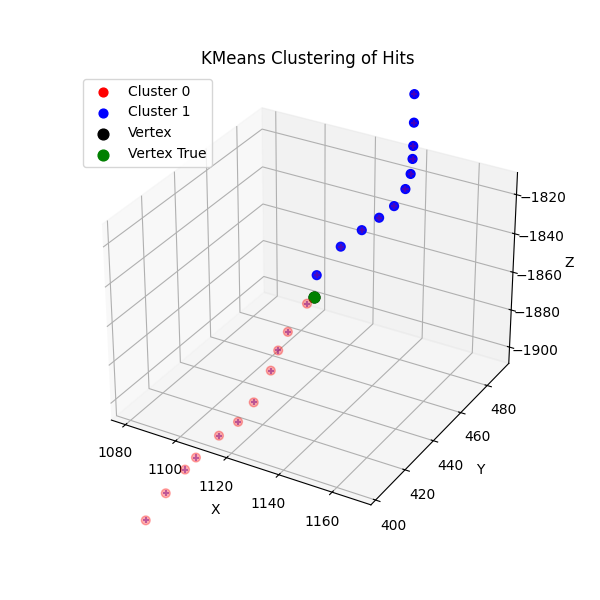

1.5681490896622563 1.27998166596808


,particle_id,kin_energy
567,2,1.568149
930,1,1.431854


In [14]:
%matplotlib widget
file_1 = "/mnt/d/events_45_135/simulated_data/1bar/nodiff/events_45_135_nexus_773.h5"
eid_1 = 92881
hits_df = pd.read_hdf(file_1, "MC/hits")
part_df = pd.read_hdf(file_1, "MC/particles")
e1, e2 = cluster_hits_to_e(hits_df, part_df, eid_1, "nodiff", 1, z_shift, vertex=None, plot=True)
print(e1, e2)
part_df[(part_df.primary == 1) & (part_df.event_id == eid_1)][["particle_id", "kin_energy"]]

In [47]:
true_reco_diff = []
true_reco_pred_diff = []

for index, row in vertex_df.iterrows():
    eid = row["event_id"]
    diffusion = row["diffusion"]
    vertex_pred = row["x_pred"], row["y_pred"], row["z_pred"]
    #getting hits info
    h5_file_key = int((int(eid)/120)-1)
    
    if diffusion == "nodiff":
        h5_diff = "nexus"
    else:
        h5_diff = f"{diffusion}_smear"
        
    h5_file_name = f"events_45_135_{h5_diff}_{h5_file_key}.h5"
    h5_dir = f"/mnt/d/events_45_135/simulated_data/1bar/{diffusion}"
    h5_path = os.path.join(h5_dir, h5_file_name)
    
    hits_df = pd.read_hdf(h5_path, "MC/hits")
    part_df = pd.read_hdf(h5_path, "MC/particles")
    
    ke1_true, ke2_true = get_true_KE(eid, part_df)
    ke1_reco, ke2_reco = cluster_hits_to_e(hits_df, part_df, eid, diffusion, 1, z_shift, vertex=None, plot=False)
    ke1_reco_pred, ke2_reco_pred = cluster_hits_to_e(hits_df, part_df, eid, diffusion, 1, z_shift, vertex=vertex_pred, plot=False)
    
    true_reco_ke1_diff = ke1_true - ke1_reco
    true_reco_ke2_diff = ke2_true - ke2_reco
    true_reco_pred_ke1_diff = ke1_true - ke1_reco_pred
    true_reco_pred_ke2_diff = ke2_true - ke2_reco_pred

    true_reco_diff.append(float(ke1_true - ke1_reco))
    true_reco_diff.append(float(ke2_true - ke2_reco))
    true_reco_pred_diff.append(float(ke1_true - ke1_reco_pred))
    true_reco_pred_diff.append(float(ke2_true - ke2_reco_pred))

    with open("true_reco_diff.json", "w") as f:
        json.dump(true_reco_diff, f)
    with open("true_reco_pred_diff.json", "w") as f:
        json.dump(true_reco_pred_diff, f)

applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grouping
Mean sigma group: 15
applied grou

5696


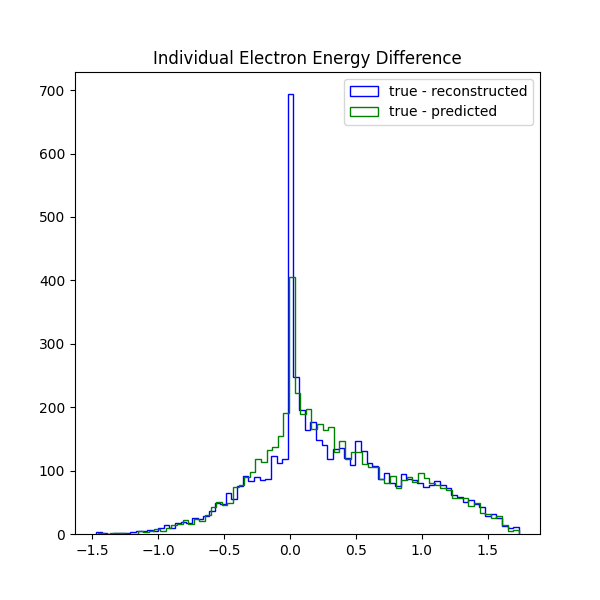

In [15]:
true_reco_diff_df = pd.read_json("true_reco_diff.json")
true_reco_pred_diff_df = pd.read_json("true_reco_pred_diff.json")
print(len(true_reco_diff_df))
bins = int(np.sqrt(len(true_reco_diff_df)))
plt.figure(figsize=(6,6))
plt.hist(true_reco_diff_df, color="blue", bins=bins, histtype="step", label="true - reconstructed")
plt.hist(true_reco_pred_diff_df, color="green", bins=bins, histtype="step", label="true - predicted")
plt.title("Individual Electron Energy Difference")
plt.legend()
plt.show()